<a href="https://colab.research.google.com/github/noone878/data-science-2026/blob/main/Pertemuan5_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1771/510532941.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day', y='total_bill', order=day_order, ax=ax1, palette='Blues_d', errorbar=None)
/tmp/ipykernel_1771/510532941.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='time', y='tip', ax=ax3, palette='Set2', width=0.5, flierprops={"marker": "x", "markeredgecolor": "red"})
/tmp/ipykernel_1771/510532941.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Mencegah judul terpotong


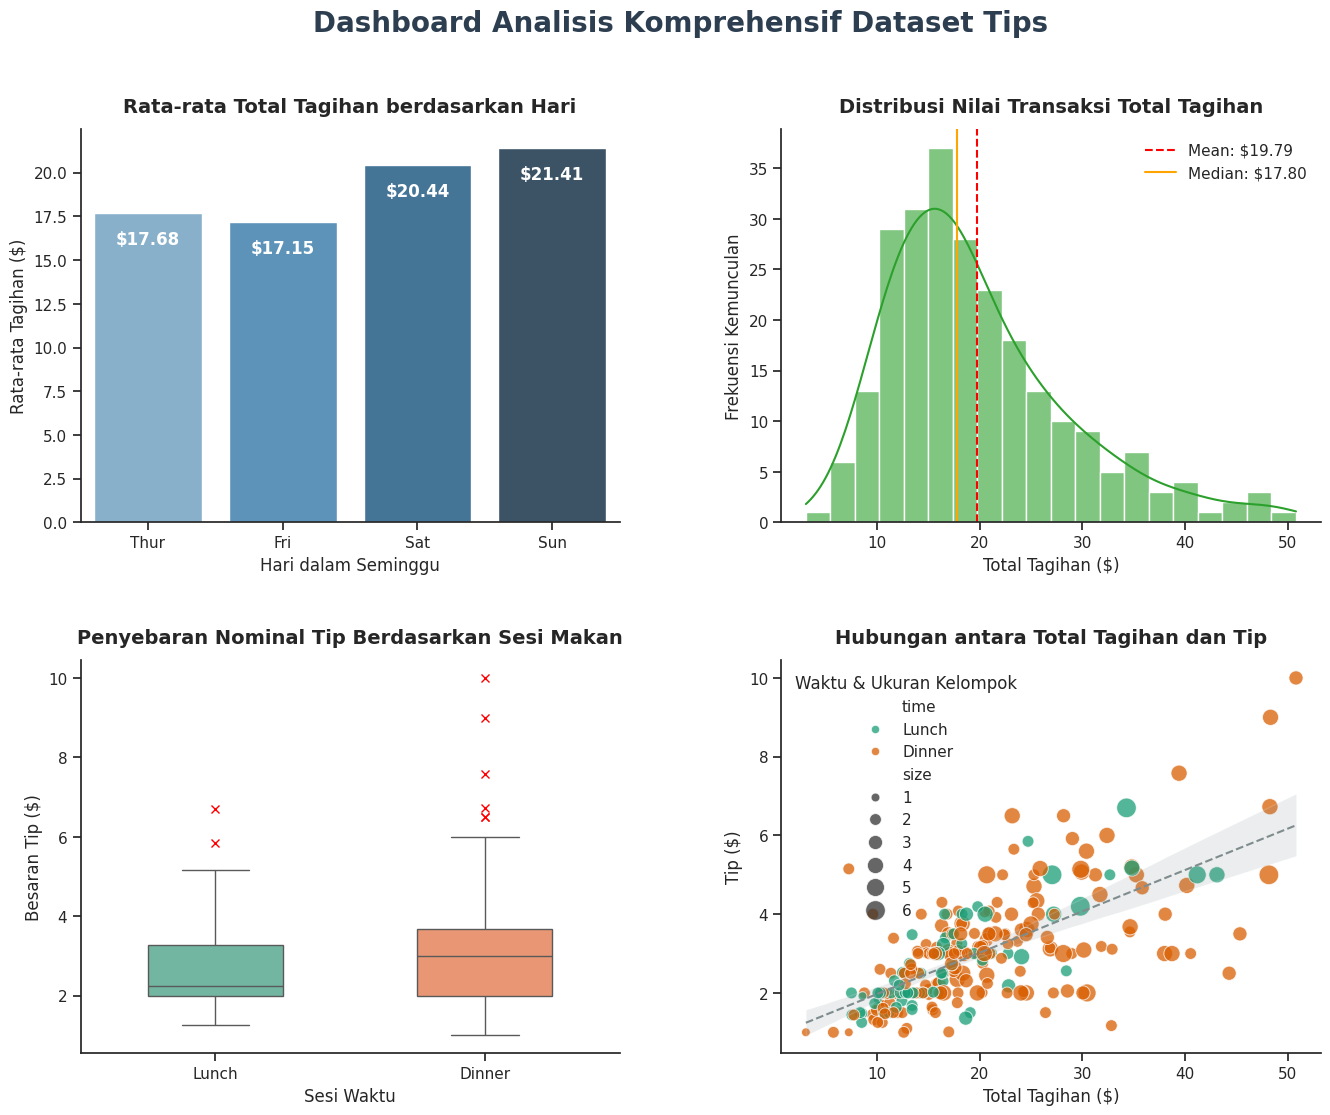

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── 1. SET THEME & LOAD DATA ──────────────────────────────────────────
sns.set_theme(style='ticks', palette='muted')
df = sns.load_dataset('tips')

# ── 2. LAYOUT MANAGEMENT (GRID 2x2) ───────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Komprehensif Dataset Tips', fontsize=20, fontweight='bold', y=0.98, color='#2c3e50')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0]) # Kiri Atas: Bar Chart
ax2 = fig.add_subplot(gs[0, 1]) # Kanan Atas: Histogram
ax3 = fig.add_subplot(gs[1, 0]) # Kiri Bawah: Boxplot
ax4 = fig.add_subplot(gs[1, 1]) # Kanan Bawah: Scatter Plot

# ── 3. GRAFIK 1: Bar Chart (Rata-rata Tagihan per Hari) ────────────────
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
sns.barplot(data=df, x='day', y='total_bill', order=day_order, ax=ax1, palette='Blues_d', errorbar=None)
ax1.set_title('Rata-rata Total Tagihan berdasarkan Hari', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Hari dalam Seminggu', fontsize=12)
ax1.set_ylabel('Rata-rata Tagihan ($)', fontsize=12)
ax1.spines[['top', 'right']].set_visible(False)

for p in ax1.patches:
    ax1.annotate(f"${p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() - 1.5),
                 ha='center', va='center', color='white', fontweight='bold', xytext=(0, 0), textcoords='offset points')

# ── 4. GRAFIK 2: Histogram (Distribusi Total Tagihan) ──────────────────
sns.histplot(data=df, x='total_bill', bins=20, kde=True, ax=ax2, color='#2ca02c', alpha=0.6)
ax2.set_title('Distribusi Nilai Transaksi Total Tagihan', fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Total Tagihan ($)', fontsize=12)
ax2.set_ylabel('Frekuensi Kemunculan', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)

mean_bill = df['total_bill'].mean()
median_bill = df['total_bill'].median()
ax2.axvline(mean_bill, color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${mean_bill:.2f}')
ax2.axvline(median_bill, color='orange', linestyle='-', linewidth=1.5, label=f'Median: ${median_bill:.2f}')
ax2.legend(frameon=False)

# ── 5. GRAFIK 3: Boxplot (Distribusi Tip Berdasarkan Waktu Makan) ──────
sns.boxplot(data=df, x='time', y='tip', ax=ax3, palette='Set2', width=0.5, flierprops={"marker": "x", "markeredgecolor": "red"})
ax3.set_title('Penyebaran Nominal Tip Berdasarkan Sesi Makan', fontsize=14, fontweight='bold', pad=12)
ax3.set_xlabel('Sesi Waktu', fontsize=12)
ax3.set_ylabel('Besaran Tip ($)', fontsize=12)
ax3.spines[['top', 'right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot (Korelasi Tagihan & Tip) ─────────────────
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size', sizes=(40, 200), palette='Dark2', alpha=0.75, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='#7f8c8d', ax=ax4, line_kws={'linestyle': '--', 'linewidth': 1.5})
ax4.set_title('Hubungan antara Total Tagihan dan Tip', fontsize=14, fontweight='bold', pad=12)
ax4.set_xlabel('Total Tagihan ($)', fontsize=12)
ax4.set_ylabel('Tip ($)', fontsize=12)
ax4.legend(title='Waktu & Ukuran Kelompok', frameon=False, loc='upper left')
ax4.spines[['top', 'right']].set_visible(False)

# ── 7. TAMPILKAN GRAFIK ──────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Mencegah judul terpotong
plt.show()

Analisis Grafik 1: Bar Chart (Rata-rata Tagihan)

1. What?: Grafik batang ini memperlihatkan rata-rata pengeluaran transaksi harian paling tinggi terjadi pada hari Minggu sebesar $21.41 dan hari Sabtu sebesar $20.44, sementara titik terendah berada di hari Jumat dengan nilai $17.15.

2. So what?: Hal ini menandakan bahwa struktur pelanggan di akhir pekan memiliki daya beli yang jauh lebih besar atau cenderung memesan menu paket kelompok yang lebih mahal dibandingkan hari kerja (weekday).

3. Now what?: Pihak manajemen restoran sebaiknya memfokuskan alokasi pelayan terbaik (top-tier servers) pada akhir pekan untuk memaksimalkan kepuasan konsumen, serta membuat promo "Hemat Jumat" untuk mendongkrak pendapatan hari Jumat yang lesu.

Analisis Grafik 2: Histogram (Distribusi Tagihan)

1. What?: Histogram menunjukkan sebaran miring ke kanan (right-skewed) dengan nilai tengah transaksi (Median) sebesar $17.79, rata-rata (Mean) $19.79, dan nilai transaksi tunggal tertinggi menyentuh angka $50.81.

2. So what?: Mayoritas pelanggan bertransaksi di rentang menengah bawah ($10 hingga $25), tetapi kehadiran kelompok konsumen elit (outliers) di atas $40 menjadi penggerak utama yang menarik nilai rata-rata menjadi lebih tinggi dari median.

3. Now what?: Restoran perlu mempertahankan kestabilan harga menu reguler di kisaran $15-$20 agar pelanggan tetap loyal, sembari meluncurkan opsi Upselling menu premium untuk menangkap potensi pasar dari pelanggan berbelanja besar.

Analisis Grafik 3: Boxplot (Distribusi Tip Sesi Makan)

1. What?: Boxplot mendeteksi nilai tengah (median) tip pada sesi Dinner ($3.00) lebih tinggi daripada sesi Lunch ($2.25), di mana variasi tip malam hari jauh lebih lebar hingga memunculkan pencilan (outlier) ekstrem sebesar $10.00.

2. So what?: Sesi makan malam terbukti menghasilkan insentif finansial yang jauh lebih besar bagi para staf restoran dikarenakan suasana makan malam yang santai memicu orang memberikan apresiasi lebih.

3. Now what?: Manajemen disarankan memberlakukan rotasi jadwal kerja (shift rotation) yang adil agar seluruh pelayan mendapatkan kesempatan yang sama untuk mengisi pos makan malam yang basah akan tip ini.

Analisis Grafik 4: Scatter Plot (Hubungan Tagihan vs Tip)

1. What?: Scatter plot memperlihatkan tren linier positif yang kuat, di mana peningkatan nilai total tagihan berbanding lurus dengan besaran tip yang diberikan, dipertegas oleh kemiringan garis regresi abu-abu.

2. So what?: Pola ini mengonfirmasi bahwa pelanggan di restoran ini secara konsisten menganut budaya pemberian tip berbasis persentase (proporsional) dari total harga makanan yang mereka beli.

3. Now what?: Fokus utama pelayan bukan lagi mencari cara memikat hati pelanggan secara personal demi tip, melainkan mendorong pelanggan memesan lebih banyak hidangan (menu bundling/add-on) karena secara otomatis akan menaikkan nilai tip mereka.